In [1]:
# load the ImageNet dataset from torchvision
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader

# set the current working directory to directory of this notebook
import os
os.chdir(os.path.dirname(os.path.abspath('__file__')))

In [43]:
# use pytorch lightning to load the dataset
from pytorch_lightning.utilities.types import EVAL_DATALOADERS
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import torch
import pytorch_lightning as pl

class CIFAR100DataModule(pl.LightningDataModule):
    def __init__(self, data_path, batch_size=128):
        super().__init__()
        self.data_path = data_path
        self.batch_size = batch_size
        self.transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),  # Global Contrast Normalization
        ])

    def prepare_data(self):
        datasets.CIFAR100(self.data_path, train=True, download=True)
        datasets.CIFAR100(self.data_path, train=False, download=True)

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            dataset = datasets.CIFAR100(self.data_path, train=True, transform=self.transform)

            # Split the dataset into training and validation set
            self.cifar100_train, self.cifar100_val = random_split(dataset, [45000, 5000])
            self.cifar100_test = datasets.CIFAR100(self.data_path, train=False, transform=self.transform)

    def train_dataloader(self):
        return DataLoader(self.cifar100_train, batch_size=self.batch_size, shuffle=True)
    
    def test_dataloader(self):
        return DataLoader(self.cifar100_test, batch_size=self.batch_size)

    def val_dataloader(self):
        return DataLoader(self.cifar100_val, batch_size=self.batch_size)


Files already downloaded and verified
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.71453285..1.7890693].


torch.Size([128, 3, 32, 32]) torch.Size([128])


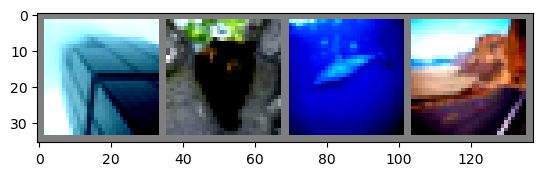

In [44]:
## show the first batch
dm = CIFAR100DataModule(data_path='datasets')
dm.prepare_data()
dm.setup()
train_loader = dm.train_dataloader()
batch = next(iter(train_loader))
print(batch[0].shape, batch[1].shape)

# show the first image
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(batch[0][:4]))

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from pytorch_lightning.callbacks import EarlyStopping


# Define the ConvNet model using torch lightning
class ConvNet(pl.LightningModule):
    def __init__(self):
        super(ConvNet, self).__init__()
        
        # Convolutional layers with corresponding configurations
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=96, kernel_size=5, stride=1, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv2 = nn.Conv2d(in_channels=96, out_channels=128, kernel_size=5, stride=1, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)
        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=5, stride=1, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=3, stride=2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(256 * 3 * 3, 2048)
        self.fc2 = nn.Linear(2048, 2048)
        self.fc3 = nn.Linear(2048, 100)  # 100 output classes

        # Dropout layers
        self.dropout1 = nn.Dropout(0.2)
        self.dropout2 = nn.Dropout(0.2)
        self.dropout3 = nn.Dropout(0.2)
        
        # Weight normalization (applied to fully connected layers)
        #nn.utils.weight_norm(self.fc1, name='weight', dim=0)
        #nn.utils.weight_norm(self.fc2, name='weight', dim=0)
        #nn.utils.weight_norm(self.fc3, name='weight', dim=0)

    def forward(self, x):
        # Layer 1 (Conv + Pool + Dropout)
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.dropout1(x)
        
        # Layer 2 (Conv + Pool + Dropout)
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.dropout2(x)
        
        # Layer 3 (Conv + Pool + Dropout)
        x = self.pool3(F.relu(self.conv3(x)))
        x = self.dropout3(x)

        # Flatten the tensor for fully connected layers
        x = x.view(-1, 256 * 3 * 3)

        # Fully connected layers with dropout and ReLU activations
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        # Output layer (Softmax for classification)
        x = self.fc3(x)
        return x
    
    def configure_optimizers(self):
        self.optimizer = optim.SGD(self.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
        # future addition
        self.lr_scheduler = None

        return self.optimizer
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.log('train_loss', loss)

        # determine the accuracy
        _, y_pred = torch.max(y_hat, dim=1)
        acc = torch.tensor(torch.sum(y_pred == y).item() / len(y), dtype=torch.float32)
        self.log('train_acc', acc * 100)
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.log('val_loss', loss)

        # determine the accuracy
        _, y_pred = torch.max(y_hat, dim=1)
        acc = torch.tensor(torch.sum(y_pred == y).item() / len(y), dtype=torch.float32)
        self.log('val_acc', acc * 100)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.log('test_loss', loss)

        # determine the accuracyz
        _, y_pred = torch.max(y_hat, dim=1)
        acc = torch.tensor(torch.sum(y_pred == y).item() / len(y), dtype=torch.float32)
        self.log('test_acc', acc * 100)

## one forward pass, showing loss, and accuracy
model = ConvNet()
x, y = batch
y_hat = model(x)
loss = F.cross_entropy(y_hat, y)
print(loss)



tensor(4.6097, grad_fn=<NllLossBackward0>)


In [53]:
## Run

# Initialize the data module
data_module = CIFAR100DataModule(data_path='datasets')

# Initialize the model
model = ConvNet()

# Define early stopping criteria
early_stop_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    min_delta=0.00,  # Minimum change needed to qualify as an improvement
    patience=3,  # Number of epochs with no improvement after which training will be stopped
    verbose=False,  # Whether to print logs in console
    mode='min'  # 'min' indicates that training will stop when the quantity monitored has stopped decreasing
)

# Initialize the trainer
trainer = pl.Trainer(max_epochs=1, accelerator='gpu', callbacks=[early_stop_callback])

# Train the model
trainer.fit(model, data_module)
# Test the model
trainer.test(model, data_module.test_dataloader())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Files already downloaded and verified
Files already downloaded and verified


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name     | Type      | Params | Mode 
------------------------------------------------
0  | conv1    | Conv2d    | 7.3 K  | train
1  | pool1    | MaxPool2d | 0      | train
2  | conv2    | Conv2d    | 307 K  | train
3  | pool2    | MaxPool2d | 0      | train
4  | conv3    | Conv2d    | 819 K  | train
5  | pool3    | MaxPool2d | 0      | train
6  | fc1      | Linear    | 4.7 M  | train
7  | fc2      | Linear    | 4.2 M  | train
8  | fc3      | Linear    | 204 K  | train
9  | dropout1 | Dropout   | 0      | train
10 | dropout2 | Dropout   | 0      | train
11 | dropout3 | Dropout   | 0      | train
------------------------------------------------
10.3 M    Trainable params
0         Non-trainable params
10.3 M    Total params
41.024    Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 352/352 [00:14<00:00, 24.81it/s, v_num=23]       

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 0: 100%|██████████| 352/352 [00:14<00:00, 23.87it/s, v_num=23]
Files already downloaded and verified
Files already downloaded and verified


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0:  58%|█████▊    | 46/79 [00:01<00:01, 28.08it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined